In [4]:
import scipy.io
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

data = scipy.io.loadmat('data/NN_training_data.mat')

In [10]:
a1, a2, a3 = 1.0, 1.0, 3.0
v0, k0 = 1 / 48.0, 1 / 48.0
b1 = (a1 - a2 - a3) / 2.0
b2 = (a2 - a3 - a1) / 2.0
b3 = (a3 - a1 - a2) / 2.0
c = np.sqrt(b1 * b2 + b2 * b3 + b3 * b1)

g0 = 8.0
h1, h2, h3 = -1.0, 0.0, 0.0
#F1, F2, F3 = 0.3027, 0.0, 0.0
F1, F2, F3 = 6.97e-2, 0.0, 0.0

@jax.jit
def dSdt(s):
    x1, x2, x3 = s[0:3]
    y1, y2, y3 = s[3:6]
    z1, z2, z3 = s[6:9]
    dx1dt = - v0 * a1**2 * x1 - c * (a1 - a3) * x2 * y3 + c * (a1 - a2) * y2 * x3 + a1 * b1 * x2 * x3 - 2 * c**2 * y2 * y3 + a1 * (y1 - z1)
    dx1dt /= a1
    dx2dt = - v0 * a2**2 * x2 - c * (a2 - a1) * x3 * y1 + c * (a2 - a3) * y3 * x1 + a2 * b2 * x3 * x1 - 2 * c**2 * y3 * y1 + a2 * (y2 - z2)
    dx2dt /= a2
    dx3dt = - v0 * a3**2 * x3 - c * (a3 - a2) * x1 * y2 + c * (a3 - a1) * y1 * x2 + a3 * b3 * x1 * x2 - 2 * c**2 * y1 * y2 + a3 * (y3 - z3)
    dx3dt /= a3
    
    dy1dt = - a3 * b3 * x2 * y3 - a2 * b2 * y2 * x3 + c * (a3 - a2) * y2 * y3 - a1 * x1 - v0 * a1**2 * y1
    dy1dt /= a1
    dy2dt = - a1 * b1 * x3 * y1 - a3 * b3 * y3 * x1 + c * (a1 - a3) * y3 * y1 - a2 * x2 - v0 * a2**2 * y2
    dy2dt /= a2
    dy3dt = - a2 * b2 * x1 * y2 - a1 * b1 * y1 * x2 + c * (a2 - a1) * y1 * y2 - a3 * x3 - v0 * a3**2 * y3
    dy3dt /= a3

    dz1dt = g0 * a1 * x1 - b3 * x2 * (z3 - h3) - b2 * x3 * (z2 - h2) + c * (z3 - h3) * y2 - c * (z2 - h2) * y3 - k0 * a1 * z1 + F1
    dz2dt = g0 * a2 * x2 - b1 * x3 * (z1 - h1) - b3 * x1 * (z3 - h3) + c * (z1 - h1) * y3 - c * (z3 - h3) * y1 - k0 * a2 * z2 + F2
    dz3dt = g0 * a3 * x3 - b2 * x1 * (z2 - h2) - b1 * x2 * (z1 - h1) + c * (z2 - h2) * y1 - c * (z1 - h1) * y2 - k0 * a3 * z3 + F3
    return jnp.array([dx1dt, dx2dt, dx3dt, dy1dt, dy2dt, dy3dt, dz1dt, dz2dt, dz3dt])

@jax.jit
def rk4_step(s, dt):
    k1 = dSdt(s)
    k2 = dSdt(s + 0.5 * dt * k1)
    k3 = dSdt(s + 0.5 * dt * k2)
    k4 = dSdt(s + dt * k3)
    return s + (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)

# Función del paso para jax.lax.scan
def step_fn(s, _):
    next_s = rk4_step(s, 4.2e-3)
    return next_s, next_s

start_idx = 0
end_idx = 6000000
s0 = jnp.array(data['u'][:, start_idx])

# Compila y simula 1,000,000 de pasos en hardware acelerado / CPU optimizado
_, traj = jax.lax.scan(step_fn, s0, None, length=end_idx - 1)
S_sim = jnp.vstack([s0, traj]).T

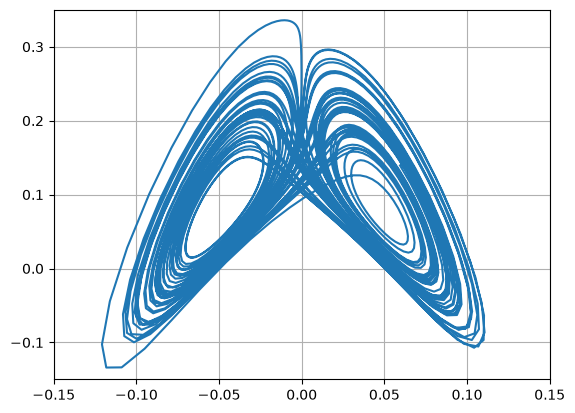

In [11]:
plt.plot(S_sim[5][3500000:5000000][::500], S_sim[3][3500000:5000000][::500])
plt.xlim(-0.15, 0.15)
plt.ylim(-0.15, 0.35)
plt.grid()

In [27]:
import jax
import jax.numpy as jnp

# Definición de constantes
a1, a2, a3 = 1.0, 1.0, 3.0
v0, k0 = 1 / 48.0, 1 / 48.0
b1 = (a1 - a2 - a3) / 2.0
b2 = (a2 - a3 - a1) / 2.0
b3 = (a3 - a1 - a2) / 2.0
c = jnp.sqrt(b1 * b2 + b2 * b3 + b3 * b1)

g0 = 8.0
h1, h2, h3 = -1.0, 0.0, 0.0
F1, F2, F3 = 6.97e-2, 0.0, 0.0

@jax.jit
def dSdt(s):
    x1, x2, x3 = s[0], s[1], s[2]
    y1, y2, y3 = s[3], s[4], s[5]
    z1, z2, z3 = s[6], s[7], s[8]
    
    dx1dt = (- v0 * a1**2 * x1 - c * (a1 - a3) * x2 * y3 + c * (a1 - a2) * y2 * x3 + a1 * b1 * x2 * x3 - 2 * c**2 * y2 * y3 + a1 * (y1 - z1)) / a1
    dx2dt = (- v0 * a2**2 * x2 - c * (a2 - a1) * x3 * y1 + c * (a2 - a3) * y3 * x1 + a2 * b2 * x3 * x1 - 2 * c**2 * y3 * y1 + a2 * (y2 - z2)) / a2
    dx3dt = (- v0 * a3**2 * x3 - c * (a3 - a2) * x1 * y2 + c * (a3 - a1) * y1 * x2 + a3 * b3 * x1 * x2 - 2 * c**2 * y1 * y2 + a3 * (y3 - z3)) / a3
    
    dy1dt = (- a3 * b3 * x2 * y3 - a2 * b2 * y2 * x3 + c * (a3 - a2) * y2 * y3 - a1 * x1 - v0 * a1**2 * y1) / a1
    dy2dt = (- a1 * b1 * x3 * y1 - a3 * b3 * y3 * x1 + c * (a1 - a3) * y3 * y1 - a2 * x2 - v0 * a2**2 * y2) / a2
    dy3dt = (- a2 * b2 * x1 * y2 - a1 * b1 * y1 * x2 + c * (a2 - a1) * y1 * y2 - a3 * x3 - v0 * a3**2 * y3) / a3

    dz1dt = g0 * a1 * x1 - b3 * x2 * (z3 - h3) - b2 * x3 * (z2 - h2) + c * (z3 - h3) * y2 - c * (z2 - h2) * y3 - k0 * a1 * z1 + F1
    dz2dt = g0 * a2 * x2 - b1 * x3 * (z1 - h1) - b3 * x1 * (z3 - h3) + c * (z1 - h1) * y3 - c * (z3 - h3) * y1 - k0 * a2 * z2 + F2
    dz3dt = g0 * a3 * x3 - b2 * x1 * (z2 - h2) - b1 * x2 * (z1 - h1) + c * (z2 - h2) * y1 - c * (z1 - h1) * y2 - k0 * a3 * z3 + F3

    return jnp.array([dx1dt, dx2dt, dx3dt, dy1dt, dy2dt, dy3dt, dz1dt, dz2dt, dz3dt])

@jax.jit
def rk4_step(s, dt):
    k1 = dSdt(s)
    k2 = dSdt(s + 0.5 * dt * k1)
    k3 = dSdt(s + 0.5 * dt * k2)
    k4 = dSdt(s + dt * k3)
    return s + (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)

# Función del paso para jax.lax.scan
def step_fn(s, _):
    next_s = rk4_step(s, 4.2e-3)
    return next_s, next_s

# Ejecución
start_idx = 0
end_idx = 6000000
s0 = jnp.array(data['u'][:, start_idx])

# Compila y simula 1,000,000 de pasos en hardware acelerado / CPU optimizado
_, traj = jax.lax.scan(step_fn, s0, None, length=end_idx - 1)

# Construir la matriz completa (9, end_idx)
S_sim = jnp.vstack([s0, traj]).T

In [ ]:
plt.plot(S_sim[5][3500000:5000000][::250], S_sim[3][3500000:5000000][::250])
plt.xlim(-0.15, 0.15)
plt.ylim(-0.15, 0.35)
plt.grid()

In [19]:
S_sim[5][1000000:3000000][::250].shape

(8000,)